In [1]:
%load_ext autoreload
# %load_ext kedro.ipython
%load_ext kedro.extras.extensions.ipython
# %reload_kedro
# %autoreload 2
%config Completer.use_jedi = False  ## (To fix autocomplete)

import matplotlib
matplotlib.use('QtAgg')  # kein GUI-Fenster, nur Dateien speichern
import matplotlib.pyplot as plt
from plot.plot import *
import pandas as pd
import numpy as np
import Krylov.krylov as kry
import Krylov.get_test_input as gti
from scipy.signal import medfilt

2026-07-04 13:25:36,669 - kedro.framework.session.store - INFO - `read()` not implemented for `SQLiteStore`. Assuming empty store.


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/kedro/framework/context/context.py:488: UserWarning: Credentials not found in your Kedro project config.
No files found in ['/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/base', '/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/local'] matching the glob pattern(s): ['credentials*', 'credentials*/**', '**/credentials*']
  warn(f"Credentials not found in your Kedro project config.\n{str(exc)}")
/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/fsspec/spec.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if pa_version and LooseVersion(pa_version) < LooseVersion("2.0"):
/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models

2026-07-04 13:25:45,223 - root - INFO - ** Kedro project wPCC_pipeline
2026-07-04 13:25:45,226 - root - INFO - Defined global variable `context`, `session`, `catalog` and `pipelines`
2026-07-04 13:25:47,527 - root - INFO - Registered line magic `run_viz`


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/src/Krylov/krylov.py:1398: DeprecationWarning: invalid escape sequence '\s'
  prop_openwater = pd.read_csv(f, sep='\s+', header=None, names=['J', 'KT', 'KQ'])


In [2]:
%reload_kedro
kry_p = catalog.load("wlfa.krylov_parameters")
ship_parameters = catalog.load("wlfa.ship_data")
ship_resistance = catalog.load("wlfa.ship_resistance_oestermann")
prop_openwater = catalog.load("wlfa.prop_openwater")
trial_segmentation = catalog.load("wlfa.segmentation")
# data = map_data(data, )
# data_plot = TelemetryPlotter(data, t_unit="ns", timecolumn="index", relative_time=True, sensor=False)

2026-07-04 13:25:48,350 - kedro.framework.session.store - INFO - `read()` not implemented for `SQLiteStore`. Assuming empty store.


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/kedro/framework/context/context.py:488: UserWarning: Credentials not found in your Kedro project config.
No files found in ['/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/base', '/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/local'] matching the glob pattern(s): ['credentials*', 'credentials*/**', '**/credentials*']
  warn(f"Credentials not found in your Kedro project config.\n{str(exc)}")


2026-07-04 13:25:49,290 - root - INFO - ** Kedro project wPCC_pipeline
2026-07-04 13:25:49,292 - root - INFO - Defined global variable `context`, `session`, `catalog` and `pipelines`
2026-07-04 13:25:49,303 - root - INFO - Registered line magic `run_viz`
2026-07-04 13:25:49,306 - kedro.io.data_catalog - INFO - Loading data from `wlfa.krylov_parameters` (YAMLDataSet)...
2026-07-04 13:25:49,328 - kedro.io.data_catalog - INFO - Loading data from `wlfa.ship_data` (YAMLDataSet)...
2026-07-04 13:25:49,335 - kedro.io.data_catalog - INFO - Loading data from `wlfa.ship_resistance_oestermann` (CSVDataSet)...
2026-07-04 13:25:49,343 - kedro.io.data_catalog - INFO - Loading data from `wlfa.prop_openwater` (CSVDataSet)...
2026-07-04 13:25:49,347 - kedro.io.data_catalog - INFO - Loading data from `wlfa.segmentation` (ParquetDataSet)...


# loading data depening on segmentation iloc

In [3]:
trial_name = f"wlfa.{trial_segmentation.iloc[1]['segment_name']}"
# data = catalog.load(trial_name)
data = catalog.load("wlfa.test_data")


2026-07-04 13:25:49,492 - kedro.io.data_catalog - INFO - Loading data from `wlfa.test_data` (CSVDataSet)...


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(


In [4]:
import importlib
importlib.reload(kry)


test_data = gti.create_test_data(duration_s=1000, rpm=550, rudder_angle=10, fs=100)


input_columns_data = [
    "rpm_response_ps", "rpm_response_stb",
    "azimuth_response_ps", "azimuth_response_stb"
]
# data["SOG"] = data["SOG"]

kf = kry.Krylov_forces(
                    ship_parameters=ship_parameters, 
                    krylov_parameters=kry_p, 
                    ship_resistance=ship_resistance, 
                    prop_openwater=prop_openwater, 
                    data=test_data
                    )
df = kf.data.copy()
kf.debug = False  # einschalten


# kf.data =kf.map_column_names_for_simulation(
#     input_columns_data=input_columns_data,
#     geopos=["latitude", "longitude"],
# )

# kf.data["delta_r0"] = kf.data["delta_r0"]
# kf.data["delta_r1"] = kf.data["delta_r0"]
# print(kf.data[["delta_r0", "delta_r1", "N0", "N1"]].describe())

# for col in ["delta_r0", "delta_r1", "N0", "N1"]:
#     kf.data[col] = medfilt(kf.data[col], kernel_size=7)

# N0/N1: percent → RPM  (max 1050 RPM = 100%)
# calc_pod_forces divides by 60 internally to get RPS
# N_MAX_RPM = 1050
# for col in ["N0", "N1"]:
#     kf.data[col] = kf.data[col] / 100 * N_MAX_RPM
print(kf.data.keys())
# kf.data.index = kf.data.index / 1e9
# x0_ = kf.get_x0(sog_col="SOG", cog_col="COG", heading_col="heading", rot_col="rate_of_turn")
x0_test = [0]*6
# x0_test[3] = x0_[3]

print(f"x0_test: {x0_test}")
print(f"N0 range: {kf.data['N0'].min():.1f} – {kf.data['N0'].max():.1f} RPM")


df = kf.simulate(x0_test)
# kf.forces(x0_=[0,0,0, df["u"].iloc[-1], df["v"].iloc[-1], df["r"].iloc[-1]],
#           input=np.array([440, 440, 20*np.pi/180, 20*np.pi/180]),
#           input_columns=kf.input_columns, sd=kf.sd, eps=kf.eps)
kf.debug = False  # wieder ausschalten
# kf.hydro_mass_dict["izz"]

m11: 823.74, m22: 15815.89, m66: 1058291.75
Akxx: 2.09, Akyy: 1.99
m11: 1724.53, m22: 31521.12, m66: 286548.50, izz: 409355.00
Index(['N0', 'N1', 'delta_r0', 'delta_r1'], dtype='object')
x0_test: [0, 0, 0, 0, 0, 0]
N0 range: 550.0 – 550.0 RPM
Initializing simulation with Krylov forces...
Starting integration...


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1846: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])  # type: ignore[arg-type]


Integration completed.
Integration failed: Required step size is less than spacing between numbers.


ValueError: Shape of passed values is (288, 6), indices imply (100001, 6)

In [ ]:
print(kf.Corr_x, kf.Corr_y, kf.Corr_n, kf.sd.LB)
print(df["r"].iloc[-5:])


2.0 1.9956268758434814 1.994314938596526 11.30978260869565
999.96     0.000993
999.97     0.000993
999.98     0.000993
999.99     0.000993
1000.00    0.000993
Name: r, dtype: float64


In [ ]:
print(kf.cns)

df.reset_index(inplace=True)
df_plot = TelemetryPlotter(df, t_unit="s", timecolumn="index", relative_time=True, sensor=False)


[]


type: <class 'int'>, <class 'numpy.float64'>
Filtering window: 0 → 100000, rows selected.


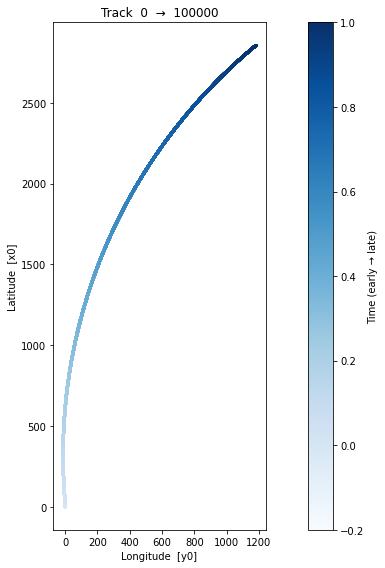

In [ ]:
%matplotlib inline

# df_plot.plot_azimuth(start= 0, end = df.index[-1], columns= ["psi"], heading_col= "psi", figsize= (12, 8), invert_y= False)
df_plot.plot_track(start= df.index[0], end = df.index[-1], lat_col= "x0", lon_col="y0", figsize= (12, 8), invert_y= False)
# display(df)

In [ ]:
print(df["u"].min(), df["u"].max())

0.0 3.2618963228312015


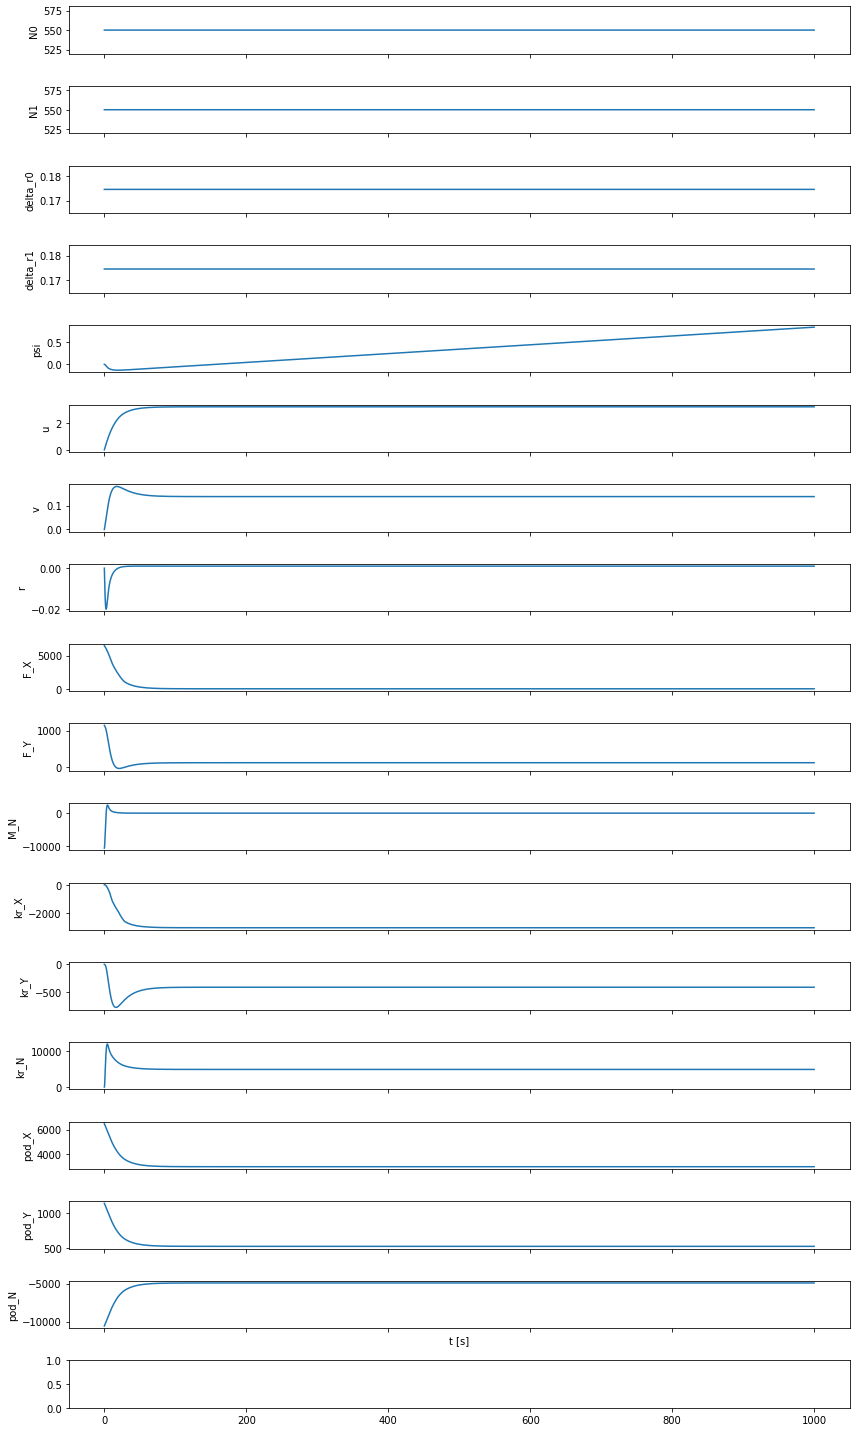

In [ ]:
columns = ["N0", "N1", "delta_r0", "delta_r1", "psi", "u", "v", "r", "F_X", "F_Y", "M_N", "kr_X", "kr_Y", "kr_N", "pod_X", "pod_Y", "pod_N"]
fig, axes = plt.subplots(len(columns)+1, 1, figsize=(12, 20), sharex=True)

for ax, col in zip(axes, columns):
    ax.plot(df["index"], df[col])
    ax.set_ylabel(col)

# axes[-1].plot(df["y0"], df["x0"])

axes[-2].set_xlabel("t [s]")

fig.tight_layout()
plt.show()

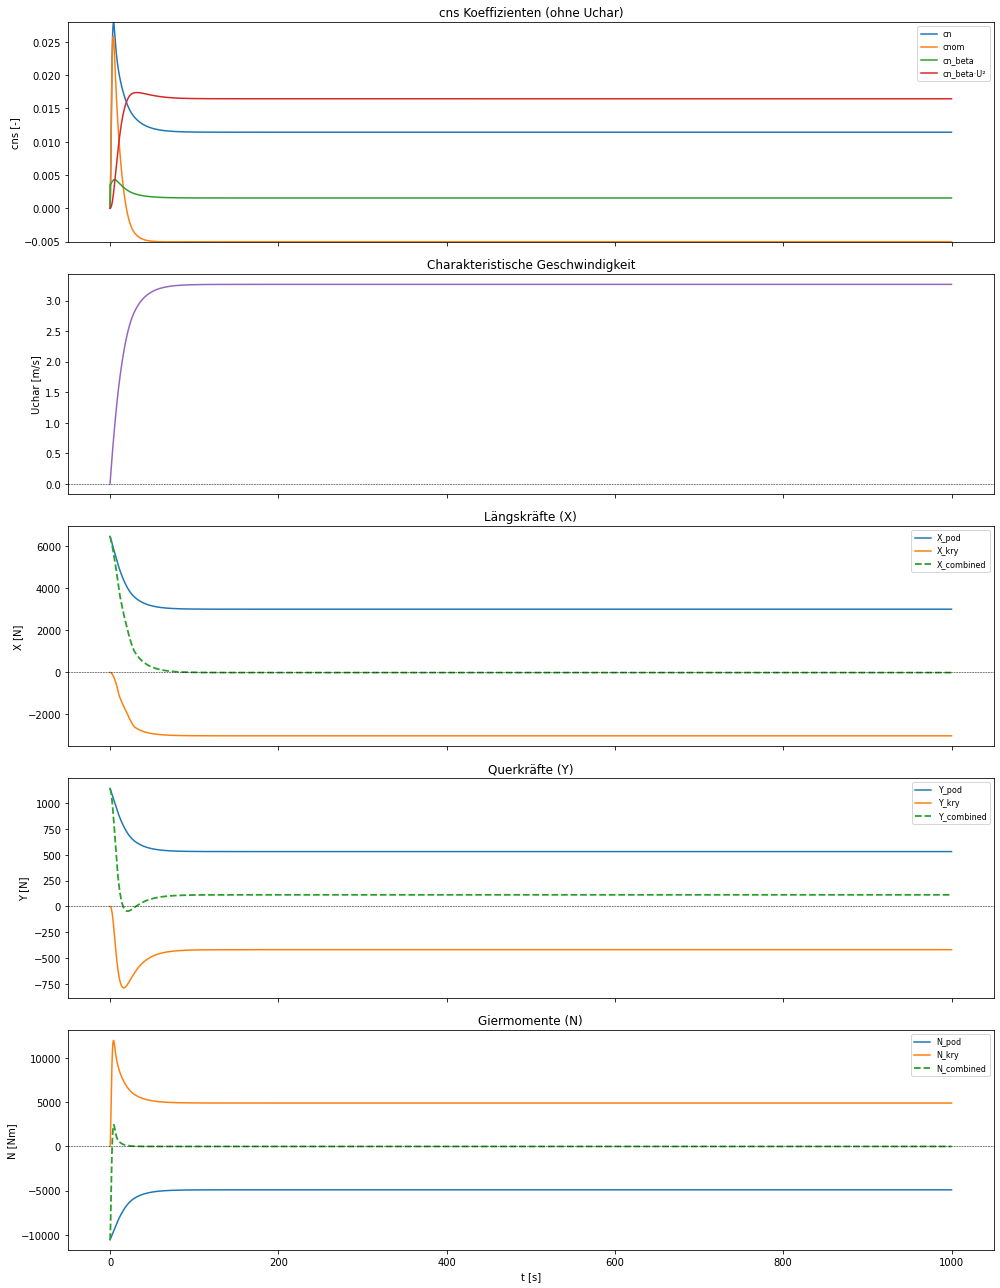

In [ ]:
%matplotlib inline
import numpy as np

# cns per row: [cn, cnom, cn_beta, Uchar, cn_beta·U²]
cns_labels = ["cn", "cnom", "cn_beta", "Uchar", "cn_beta·U²"]
cns_arr = np.array(df["cns"].tolist())

t = df["index"]

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

# --- 1: cns ohne Uchar, gemeinsame y-Skalierung ---
idx_no_uchar = [0, 1, 2, 4]
y_all = cns_arr[:, idx_no_uchar]
axes[0].set_ylim(y_all.min(), y_all.max())
for i in idx_no_uchar:
    axes[0].plot(t, cns_arr[:, i], label=cns_labels[i])
axes[0].set_ylabel("cns [-]")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("cns Koeffizienten (ohne Uchar)")

# --- 2: Uchar ---
axes[1].plot(t, cns_arr[:, 3], color="C4")
axes[1].axhline(y=0, color="k", lw=0.5, ls="--")
axes[1].set_ylabel("Uchar [m/s]")
axes[1].set_title("Charakteristische Geschwindigkeit")


# --- 3: X-Kräfte ---
axes[2].plot(t, df["pod_X"], label="X_pod",      color="C0")
axes[2].plot(t, df["kr_X"],  label="X_kry",      color="C1")
axes[2].plot(t, df["F_X"],   label="X_combined", color="C2", ls="--", lw=1.8)
axes[2].axhline(y=0, color="k", lw=0.5, ls="--")
axes[2].set_ylabel("X [N]")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].set_title("Längskräfte (X)")

# --- 4: Y-Kräfte ---
axes[3].plot(t, df["pod_Y"], label="Y_pod",      color="C0")
axes[3].plot(t, df["kr_Y"],  label="Y_kry",      color="C1")
axes[3].plot(t, df["F_Y"],   label="Y_combined", color="C2", ls="--", lw=1.8)
axes[3].axhline(y=0, color="k", lw=0.5, ls="--")
axes[3].set_ylabel("Y [N]")
axes[3].legend(loc="upper right", fontsize=8)
axes[3].set_title("Querkräfte (Y)")

# --- 5: N-Momente ---
axes[4].plot(t, df["pod_N"], label="N_pod", color="C0")
axes[4].plot(t, df["kr_N"],  label="N_kry", color="C1")
axes[4].plot(t, df["M_N"],   label="N_combined", color="C2", ls="--", lw=1.8)
axes[4].axhline(y=0, color="k", lw=0.5, ls="--")
axes[4].set_ylabel("N [Nm]")
axes[4].set_xlabel("t [s]")
axes[4].legend(loc="upper right", fontsize=8)
axes[4].set_title("Giermomente (N)")

fig.tight_layout()
plt.show()
